# Iniciación de paquetes

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

# Lectura de Dataframes

In [2]:
salarios = pd.read_csv('Salary_Data_Based_country_and_race.csv')
llamadas = pd.read_csv('simulated_call_centre.csv')

# Análisis de sueldos para personas Senior y Junior

In [3]:
salarios

,Unnamed: 0,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race
0,0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,UK,White
1,1,28.0,Female,Master's,Data Analyst,3.0,65000.0,USA,Hispanic
2,2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Canada,White
3,3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,USA,Hispanic
4,4,52.0,Male,Master's,Director,20.0,200000.0,USA,Asian
...,...,...,...,...,...,...,...,...,...
6699,6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0,UK,Mixed
6700,6700,32.0,Male,High School,Sales Associate,3.0,50000.0,Australia,Australian
6701,6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0,China,Chinese
6702,6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0,China,Korean


In [4]:
# 1. Filtramos el DataFrame para obtener solo a los Sales Associate
asesores_de_ventas = salarios[salarios['Job Title'] == 'Sales Associate']

# 2. Mostramos los salarios individuales (puedes ver más columnas si lo deseas)
print("Listado de salarios para Sales Associates:")
print(asesores_de_ventas[['Job Title', 'Salary']])


# 3. Calculamos la media salarial
media_salarial = asesores_de_ventas['Salary'].mean()

print(f"\nLa media salarial de los Sales Associates es: ${media_salarial:,.2f}")

Listado de salarios para Sales Associates:
            Job Title   Salary
3     Sales Associate  60000.0
91    Sales Associate  40000.0
4880  Sales Associate  30000.0
4893  Sales Associate  30000.0
4906  Sales Associate  30000.0
...               ...      ...
6644  Sales Associate  50000.0
6661  Sales Associate  35000.0
6672  Sales Associate  50000.0
6689  Sales Associate  35000.0
6700  Sales Associate  50000.0

[70 rows x 2 columns]

La media salarial de los Sales Associates es: $35,857.14


In [5]:
# Junior: 0 a 2 años
asesores_jr = asesores_de_ventas[asesores_de_ventas['Years of Experience'].between(0, 2)]

# Semi-Senior: más de 2 hasta 5 años
asesores_ssr = asesores_de_ventas[asesores_de_ventas['Years of Experience'].between(2.1, 5)]

# Senior: más de 5 años
asesores_sr = asesores_de_ventas[asesores_de_ventas['Years of Experience'] > 5]

Ahora veamos los sueldos de gente con poca experiencia contra los que tienen mas

In [6]:
print(asesores_jr.info())
print(asesores_ssr.info())
print(asesores_sr.info())

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 4880 to 6689
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           50 non-null     int64  
 1   Age                  50 non-null     float64
 2   Gender               50 non-null     object 
 3   Education Level      50 non-null     object 
 4   Job Title            50 non-null     object 
 5   Years of Experience  50 non-null     float64
 6   Salary               50 non-null     float64
 7   Country              50 non-null     object 
 8   Race                 50 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 3.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 91 to 6700
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           19 non-null     int64  
 1   Age                  19 no

In [7]:
salario_medio_jr = asesores_jr['Salary'].mean()
salario_medio_ssr = asesores_ssr['Salary'].mean()
salario_medio_sr = asesores_sr['Salary'].mean()
print(f'El salario medio de un asesor junior es de {(salario_medio_jr/12)*0.8436:,.2f} euros')
print(f'El salario medio de un asesor semi-senior es de {(salario_medio_ssr/12)*0.8436:,.2f} euros')
print(f'El salario medio de un asesor senior es de {(salario_medio_sr/12)*0.8436:,.2f} euros')

El salario medio de un asesor junior es de 2,123.06 euros
El salario medio de un asesor semi-senior es de 3,478.00 euros
El salario medio de un asesor senior es de 4,218.00 euros


Estos son los datos que vamos a tomar para hacer nuestro estudio de optimización económica

# Análisis de tasas de llegada y salida aproximadamente

In [8]:
llamadas

,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
0,1,2021-01-01,1,8:00:00 AM,8:00:00 AM,8:14:22 AM,0,863,True
1,2,2021-01-01,2,8:02:42 AM,8:02:42 AM,8:07:31 AM,0,289,True
2,3,2021-01-01,3,8:08:24 AM,8:08:24 AM,8:10:13 AM,0,108,True
3,4,2021-01-01,4,8:09:37 AM,8:09:37 AM,8:13:45 AM,0,247,True
4,5,2021-01-01,5,8:11:10 AM,8:11:10 AM,8:15:28 AM,0,258,True
...,...,...,...,...,...,...,...,...,...
51703,51704,2021-12-31,267,5:50:10 PM,5:50:10 PM,5:57:26 PM,0,436,True
51704,51705,2021-12-31,268,5:50:31 PM,5:50:31 PM,5:54:55 PM,0,265,True
51705,51706,2021-12-31,269,5:51:29 PM,5:51:29 PM,5:54:26 PM,0,177,True
51706,51707,2021-12-31,270,5:53:10 PM,5:54:26 PM,5:57:50 PM,76,204,False


Vamos a ver cuanta gente llama cada mes, de esa forma encontramos un lambda para cada mes y luego hacemos la media de todos esos lambdas para ver el lambda que tomamos para optimizar nuestro negocio

In [9]:
import pandas as pd

# 1. Asegurar formato de fecha y tiempo
llamadas['date'] = pd.to_datetime(llamadas['date'])

# Unimos la fecha y la hora para que pandas pueda extraer la hora correctamente
# (Esto soluciona el problema de que los pesos salgan en 0.0)
llamadas['call_started'] = pd.to_datetime(
    llamadas['date'].dt.strftime('%Y-%m-%d') + ' ' + llamadas['call_started'].astype(str)
)

# 2. Cálculos generales
total_llamadas = len(llamadas)
dias_operativos = llamadas['date'].dt.date.nunique()
horas_totales = dias_operativos * 10  # Asumiendo jornada de 10 horas

lambda_medio = total_llamadas / horas_totales

# 3. Definir jornada (ejemplo: de 8:00 a 17:59)
horas_jornada = range(8, 18)
pesos_lambda = []

for h in horas_jornada:
    # FILTRO CORRECTO: Ahora buscamos la hora en la columna que sí tiene tiempo
    df_hora = llamadas[llamadas['call_started'].dt.hour == h]
    
    n_llamadas = len(df_hora)
    
    # Calculamos lambda para esa hora específica (promedio de llamadas en esa hora)
    lambda_h = n_llamadas / dias_operativos 
    
    # El peso es la relación entre la demanda de esa hora y el promedio general
    peso_lambda = lambda_h / lambda_medio
    pesos_lambda.append(round(peso_lambda, 4))

# 4. Mostrar resultados
print(f"Total de llamadas en el año: {total_llamadas}")
print(f"Días de operación detectados: {dias_operativos}")
print(f"λ medio anual: {lambda_medio:.2f} clientes/hora")
print(f"Los pesos de los lambdas para las horas {list(horas_jornada)} son:")
print(pesos_lambda)

Total de llamadas en el año: 51708
Días de operación detectados: 261
λ medio anual: 19.81 clientes/hora
Los pesos de los lambdas para las horas [8, 9, 10, 11, 12, 13, 14, 15, 16, 17] son:
[1.0509, 0.9861, 0.9867, 0.9869, 1.0126, 1.0169, 1.0192, 1.026, 1.0105, 0.9043]


El dataset que hemos elegido es evidente que está muy limpio y uniformado ya que los pesos siguen una distirbucion uniforme => vamos a establecer nuestros propios lambdas ya que en la vida real los clientes no funcionan así, de esta forma definimos pesos = [0.8, 1.2, 1.4, 1.1, 0.7, 0.6, 1.2, 1.1, 1.0, 0.9], pero eso lo usaremos dentro de un rato, primero vamos a ver en regimen estacionario como funciona el sistema y cuantos asesores son los optimos para nuestro sistema, suponiendo que cada asesor atiende con un mu = 3 de media aunque ya veremos despues en la configuracion de los equipos que eso no va a ocurrir asi.

Como en principio estamos respetando el estatuto de trrabajadores legal en España, debemos respetar la jornada de 40h semanales, gracias al hecho de que la distribución de los lambdas en este caso siguen una distribución uniforme, podemos tomar el lambda de 20 y seguir con nuestros pesos diseñados para seguir el comportamiento natural humano y poder ver como los distintos equipos tienen o no capacidad para limpiar las colas que se forman

# Métricas iniciales

In [10]:
import math

def metricas_estaticas(lambda_tasa, mu, s):
   
    rho = lambda_tasa / (s * mu)

    termino_sumatorio = sum([(lambda_tasa/mu)**n / math.factorial(n) for n in range(s)])
    termino_cola = ((lambda_tasa/mu)**s / (math.factorial(s) * (1 - rho)))
    pi0 = 1 / (termino_sumatorio + termino_cola)
    
  
    Lq = (pi0 * ((lambda_tasa/mu)**s) * rho) / (math.factorial(s) * (1 - rho)**2)
    Wq = Lq / lambda_tasa
    W = Wq + (1/mu)
    L = lambda_tasa * W
    
    # Devolvemos un diccionario con todo
    return {
        "rho": round(rho, 3),
        "Lq": round(Lq, 3),
        "Wq_min": round(Wq*60, 3),
        "L": round(L, 3),
        "lambda": round(lambda_tasa, 3),
        "mu": mu,
        "servidores": s
    }

Aún no nos interesa la optimización del dinero, de momento vamos a fijarnos en los factores de utilización y ocupacion de las colas

In [11]:
metricas_teoricas7 = metricas_estaticas(20, 3, 7)
metricas_teoricas8 = metricas_estaticas(20, 3, 8)
metricas_teoricas9 = metricas_estaticas(20, 3, 9)
print('Aqui no tenemos en cuenta el dinero que cuesta un cliente en cola ni los sueldos cada asesor')
print('estadisticas con 7 servidores:', metricas_teoricas7)
print('estadisticas con 8 servidores:', metricas_teoricas8)
print('estadisticas con 9 servidores:', metricas_teoricas9)


Aqui no tenemos en cuenta el dinero que cuesta un cliente en cola ni los sueldos cada asesor
estadisticas con 7 servidores: {'rho': 0.952, 'Lq': 17.223, 'Wq_min': 51.668, 'L': 23.889, 'lambda': 20, 'mu': 3, 'servidores': 7}
estadisticas con 8 servidores: {'rho': 0.833, 'Lq': 2.663, 'Wq_min': 7.99, 'L': 9.33, 'lambda': 20, 'mu': 3, 'servidores': 8}
estadisticas con 9 servidores: {'rho': 0.741, 'Lq': 0.895, 'Wq_min': 2.685, 'L': 7.562, 'lambda': 20, 'mu': 3, 'servidores': 9}


Se puede ver como en regimen estático el sistema con 7 servidores se colapsa => si simulamos un sistema con 7 servidores, a la mínima que haya un pequeño pico de demanda la cola va a crecer sin fin y los asesores van a estar abarrotados

En cambio si disponemos de 8 o 9 asesores los factores de utilizacion del sistema están mucho mas equilibrados y pueden soportar puntos criticos de demanda con unos tiempos de espera de 8 minutos (8 asesores) y 2.7 minutos (9 asesores).
Es evidente que el sistema con 9 servidores va a funcionar muy fluido pero puede ser qu se pague demasiado dinero en asesores => eso es lo que vamos a analizar y tambien que configuracion de equipo puede ser la optima ya que no es lo mismo 9 asesores semi-senior que 5 senior y 4 junior etc.
De esta forma pasamos a la simulación

# Función de simulación de llegadas y salidas

In [12]:
def simular_jornada(lambda_base: float, pesos: np.ndarray, mus: np.ndarray) -> np.ndarray:

    # ── Llegadas vectorizadas ──────────────────────────────────────────────
    tiempos = []
    t = 0.0
    for hora, peso in enumerate(pesos):
        tasa = lambda_base * peso
        if tasa <= 0:
            t = float(hora + 1)
            continue
        if t < float(hora):
            t = float(hora)
        # Generar todos los intertiempos de la hora de una vez
        # E[llegadas/hora] = tasa → generamos tasa*3 como buffer holgado
        buffer = int(tasa * 4) + 20
        gaps = np.random.exponential(1 / tasa, size=buffer)
        ts = t + np.cumsum(gaps)
        mask = ts < hora + 1
        if mask.any():
            tiempos.append(ts[mask])
            t = ts[mask][-1]
        else:
            t = ts[0]  # el primero ya pasó la hora

    if not tiempos:
        return np.array([])

    llegadas = np.concatenate(tiempos)

    # ── Servicio con desempate aleatorio ───────────────────────────────────
    s = len(mus)
    n = len(llegadas)
    disponibilidad = np.zeros(s)

    # Pre-generar TODOS los tiempos de servicio de una vez por servidor
    # Usamos un pool por mu único para evitar el bucle por cliente
    servicios_pool = {mu: iter(np.random.exponential(1/mu, size=n + 10))
                      for mu in np.unique(mus)}

    esperas = np.empty(n)
    for i, llegada in enumerate(llegadas):
        # Desempate aleatorio: añadir ruido tiny al mínimo evita siempre elegir idx 0
        idx = np.argmin(disponibilidad + np.random.uniform(0, 1e-12, s))
        libre = disponibilidad[idx]
        inicio = max(llegada, libre)
        esperas[i] = inicio - llegada
        disponibilidad[idx] = inicio + next(servicios_pool[mus[idx]])

    return esperas


def registrar_experimento(nombre: str, n_iter: int, lambda_base: float,
                           pesos: list, lista_asesores: list, coste_espera_h: float) -> pd.DataFrame:

    pesos_arr = np.array(pesos)
    mus       = np.array([a['mu']   for a in lista_asesores])
    costes    = np.array([a['coste'] for a in lista_asesores])
    s         = len(lista_asesores)

    HORAS_JORNADA      = len(pesos)
    coste_fijo_dia     = costes.sum() * HORAS_JORNADA
    mu_medio           = mus.mean()
    lambda_efectiva    = lambda_base * pesos_arr.mean()
    rho                = lambda_efectiva / (s * mu_medio)
    coste_wait_h_inv   = coste_espera_h  # alias para claridad

    # Pre-allocar arrays de resultados
    wq_iter    = np.empty(n_iter)
    cost_iter  = np.empty(n_iter)

    for i in range(n_iter):
        esperas = simular_jornada(lambda_base, pesos_arr, mus)
        if esperas.size:
            wq_iter[i]   = esperas.mean() * 60          # → minutos
            cost_iter[i] = esperas.sum() * coste_wait_h_inv
        else:
            wq_iter[i]   = 0.0
            cost_iter[i] = 0.0

    coste_espera_medio = cost_iter.mean()

    return pd.DataFrame([{
        "Escenario":                  nombre,
        "Iteraciones":                n_iter,
        "Lambda Base":                lambda_base,
        "Num Asesores":               s,
        "Mu Promedio":                round(mu_medio, 2),
        "Coste Espera (€/h)":         coste_wait_h_inv,
        "Configuración":              f"L={lambda_base}, S={s}, Mu={round(mu_medio,1)}",
        "Wq Medio (min)":             round(wq_iter.mean(), 2),
        "Incertidumbre (Std Dev min)": round(wq_iter.std(), 2),
        "Coste Salarios (€/día)":     coste_fijo_dia,
        "Coste Espera Medio (€/día)": round(coste_espera_medio, 2),
        "Coste Total Medio (€/día)":  round(coste_fijo_dia + coste_espera_medio, 2),
        "Factor de utilización medio": round(rho, 2)
    }])

In [13]:

# Para los análisis posteriores, dividimos la generación de llegadas y la atención
# en dos funciones reutilizables, de modo que los bucles a continuación sigan
# usando nomenclatura "generacion_llegadas" y "simulacion_atencion".
def generacion_llegadas(lambda_base: float, pesos: list) -> np.ndarray:
    """Devuelve un vector con los tiempos de llegada (horas) para una jornada.

    El algoritmo es idéntico al de `simular_jornada` pero se limita a calcular
    los instantes de llegada sin simular los servicios.
    """
    tiempos = []
    t = 0.0
    for hora, peso in enumerate(pesos):
        tasa = lambda_base * peso
        if tasa <= 0:
            t = float(hora + 1)
            continue
        if t < float(hora):
            t = float(hora)
        buffer = int(tasa * 4) + 20
        gaps = np.random.exponential(1 / tasa, size=buffer)
        ts = t + np.cumsum(gaps)
        mask = ts < hora + 1
        if mask.any():
            tiempos.append(ts[mask])
            t = ts[mask][-1]
        else:
            t = ts[0]
    if not tiempos:
        return np.array([])
    return np.concatenate(tiempos)


def simulacion_atencion(equipo: list, llegadas: np.ndarray) -> np.ndarray:
    """Dado un equipo y los tiempos de llegada, devuelve las esperas para cada
    cliente (en horas)."""
    s = len(equipo)
    if s == 0 or llegadas.size == 0:
        return np.array([])

    mus = np.array([a['mu'] for a in equipo])
    disponibilidad = np.zeros(s)
    n = len(llegadas)

    servicios_pool = {mu: iter(np.random.exponential(1 / mu, size=n + 10))
                      for mu in np.unique(mus)}

    esperas = np.empty(n)
    for i, llegada in enumerate(llegadas):
        idx = np.argmin(disponibilidad + np.random.uniform(0, 1e-12, s))
        libre = disponibilidad[idx]
        inicio = max(llegada, libre)
        esperas[i] = inicio - llegada
        disponibilidad[idx] = inicio + next(servicios_pool[mus[idx]])

    return esperas


# Función de creación de equipos

In [14]:
def crear_equipo(n_senior=0, n_semi_senior=0, n_junior=0, n_base=30,
                 mu_senior=4, coste_senior=30,
                 mu_semi=3.25, coste_semi=22,
                 mu_junior=2.5, coste_junior=15,
                 mu_base=3, coste_base=20):
    equipo = []
    equipo += [{'nombre': 'Senior', 'mu': mu_senior, 'coste': coste_senior}] * n_senior
    equipo += [{'nombre': 'semi-senior', 'mu': mu_semi, 'coste': coste_semi}] * n_semi_senior
    equipo += [{'nombre': 'Junior', 'mu': mu_junior, 'coste': coste_junior}] * n_junior
    return equipo

# ejemplo rápido
print(crear_equipo(n_senior=2, n_junior=3))

[{'nombre': 'Senior', 'mu': 4, 'coste': 30}, {'nombre': 'Senior', 'mu': 4, 'coste': 30}, {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}, {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}, {'nombre': 'Junior', 'mu': 2.5, 'coste': 15}]


## Ejemplos de equipos predefinidos

In [15]:
# Definimos los escenarios a probar utilizando la función `crear_equipo`
# que permite especificar el número de agentes de cada perfil.

# Equipos base
config_asesores_7 = crear_equipo(n_junior=7)
config_asesores_6 = crear_equipo(n_junior=6)
config_asesores_5 = crear_equipo(n_junior=5)
config_asesores_8 = crear_equipo(n_junior=8)
config_asesores_9 = crear_equipo(n_junior=9)

# Equipos mixtos (senior / junior)
config_asesores_7_mixtos_1 = crear_equipo(n_senior=4, n_junior=3)
config_asesores_7_mixtos_2 = crear_equipo(n_senior=3, n_junior=4)
config_asesores_8_mixtos_1 = crear_equipo(n_senior=4, n_junior=4)
config_asesores_8_mixtos_2 = crear_equipo(n_senior=3, n_junior=5)
config_asesores_6_mixtos_1 = crear_equipo(n_senior=3, n_junior=3)
config_asesores_6_mixtos_2 = crear_equipo(n_senior=2, n_junior=4)

# Configuraciones sólo senior
config_asesores_4_senior = crear_equipo(n_senior=4)
config_asesores_5_senior = crear_equipo(n_senior=5)
config_asesores_6_senior = crear_equipo(n_senior=6)

# Configuración sólo junior
config_asesores_8_junior = crear_equipo(n_junior=8)

# Variables de resultados

## Resultados en escenarios de barrido de staff en días intermedios

In [16]:
experimentos1 = []
pesos_dia = [0.8, 1.2, 1.4, 1.1, 0.7, 0.6, 1.2, 1.1, 1.0, 0.9]
iteraciones = 500


# Escenario 1
experimentos1.append(registrar_experimento("Base (9 asesores)", iteraciones, 20, pesos_dia, config_asesores_9, 35))

# Escenario 2
experimentos1.append(registrar_experimento("Base (8 asesores)", iteraciones, 20, pesos_dia, config_asesores_8, 35))

# Escenario 3
experimentos1.append(registrar_experimento("Base (7 asesores)", iteraciones, 20, pesos_dia, config_asesores_7, 35))

# Escenario 4
experimentos1.append(registrar_experimento("Base (6 asesores)", iteraciones, 20, pesos_dia, config_asesores_6, 35))

# Escenario 5
experimentos1.append(registrar_experimento("Base (5 asesores)", iteraciones, 20, pesos_dia, config_asesores_5, 35))

# Escenario 6
experimentos1.append(registrar_experimento("Alta demanda (9 asesores)", iteraciones, 25, pesos_dia, config_asesores_9, 35))

# Escenario 7
experimentos1.append(registrar_experimento("Alta demanda (7 asesores)", iteraciones, 25, pesos_dia, config_asesores_7, 35))

# Escenario 8
experimentos1.append(registrar_experimento("Alta demanda (8 asesores)", iteraciones, 25, pesos_dia, config_asesores_8, 35))

# Consolidamos todo en el DataFrame maestro
df_barrido_staff = pd.concat(experimentos1, ignore_index=True)

display(df_barrido_staff)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Base (9 asesores),500,20,9,2.5,35,"L=20, S=9, Mu=2.5",14.52,11.87,1350,1753.48,3103.48,0.89
1,Base (8 asesores),500,20,8,2.5,35,"L=20, S=8, Mu=2.5",27.29,18.24,1200,3245.65,4445.65,1.00
2,Base (7 asesores),500,20,7,2.5,35,"L=20, S=7, Mu=2.5",59.91,30.86,1050,7126.99,8176.99,1.14
3,Base (6 asesores),500,20,6,2.5,35,"L=20, S=6, Mu=2.5",107.55,38.79,900,12712.39,13612.39,1.33
4,Base (5 asesores),500,20,5,2.5,35,"L=20, S=5, Mu=2.5",181.56,49.52,750,21350.13,22100.13,1.60
5,Alta demanda (9 asesores),500,25,9,2.5,35,"L=25, S=9, Mu=2.5",52.69,28.80,1350,7865.57,9215.57,1.11
6,Alta demanda (7 asesores),500,25,7,2.5,35,"L=25, S=7, Mu=2.5",135.02,40.02,1050,19982.79,21032.79,1.43
7,Alta demanda (8 asesores),500,25,8,2.5,35,"L=25, S=8, Mu=2.5",88.13,33.65,1200,13099.60,14299.60,1.25


Aquí podemos observar que el dilema es si tenemos 7 asesores para todo el año que rinden bien para situaciones equilibradas u 8 que funcionan bien incluso en momentos de alta demanda

## Resultados en escenarios variados con distintos tipos de equipos mixtos

In [17]:
experimentos2 = []

# Demanda base

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (4 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (4 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_1, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (3 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_2, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (3 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_6_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_6_mixtos_1, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Mixto (2 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_6_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (2 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_6_mixtos_2, 35))

# Escenario 5:
experimentos2.append(registrar_experimento("Mixto (4 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_1, 35))
experimentos2.append(registrar_experimento("Mixto (4 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_1, 35))

# Escenario 5:
experimentos2.append(registrar_experimento("Mixto (3 senior / 5 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_2, 35))
experimentos2.append(registrar_experimento("Mixto (3 senior / 5 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_2, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (6 senior) base", 500, 15, pesos_dia, config_asesores_6_senior, 35))
experimentos2.append(registrar_experimento("Senior (6 senior) alta demanda", 500, 20, pesos_dia, config_asesores_6_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (5 senior) base", 500, 15, pesos_dia, config_asesores_5_senior, 35))
experimentos2.append(registrar_experimento("Senior (5 senior) alta demanda", 500, 20, pesos_dia, config_asesores_5_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Senior (4 senior) base", 500, 15, pesos_dia, config_asesores_4_senior, 35))
experimentos2.append(registrar_experimento("Senior (4 senior) alta demanda", 500, 20, pesos_dia, config_asesores_4_senior, 35))

# Escenario 1
experimentos2.append(registrar_experimento("Junior (8 junior) base", 500, 15, pesos_dia, config_asesores_8_junior, 35))
experimentos2.append(registrar_experimento("Junior (8 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_junior, 35))

# Consolidamos todo en el DataFrame maestro
df_Equipos_mixtos1 = pd.concat(experimentos2, ignore_index=True)

# Ahora puedes ver todo limpio
display(df_Equipos_mixtos1)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.17,2.31,1650,194.97,1844.97,0.64
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",11.36,10.02,1650,1372.00,3022.00,0.85
2,Mixto (3 senior / 4 junior) base,500,15,7,3.14,35,"L=15, S=7, Mu=3.1",3.64,3.69,1500,330.89,1830.89,0.68
3,Mixto (3 senior / 4 junior) alta demanda,500,20,7,3.14,35,"L=20, S=7, Mu=3.1",15.10,11.29,1500,1799.96,3299.96,0.91
4,Mixto (3 senior / 3 junior) base,500,15,6,3.25,35,"L=15, S=6, Mu=3.2",7.55,6.16,1350,686.83,2036.83,0.77
5,Mixto (3 senior / 3 junior) alta demanda,500,20,6,3.25,35,"L=20, S=6, Mu=3.2",36.87,22.77,1350,4427.60,5777.60,1.03
6,Mixto (2 senior / 4 junior) base,500,15,6,3.00,35,"L=15, S=6, Mu=3.0",12.19,9.99,1200,1110.29,2310.29,0.83
7,Mixto (2 senior / 4 junior) alta demanda,500,20,6,3.00,35,"L=20, S=6, Mu=3.0",51.31,27.15,1200,6113.12,7313.12,1.11
8,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.05,1.34,1800,95.18,1895.18,0.58
9,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",6.14,5.82,1800,740.02,2540.02,0.77


A vista del dataframe es evidente que los dos que serían mas optimos son los mixtos establecidos aquí debajo

In [18]:
experimentos3 = []

# Escenario 1
experimentos3.append(registrar_experimento("Mixto (4 senior / 3 junior) base", 500, 15, pesos_dia, config_asesores_7_mixtos_1, 35))
experimentos3.append(registrar_experimento("Mixto (4 senior / 3 junior) alta demanda", 500, 20, pesos_dia, config_asesores_7_mixtos_1, 35))

# Escenario 5:
experimentos3.append(registrar_experimento("Mixto (4 senior / 4 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_1, 35))
experimentos3.append(registrar_experimento("Mixto (4 senior / 4 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_1, 35))

# Escenario 5:
experimentos3.append(registrar_experimento("Mixto (3 senior / 5 junior) base", 500, 15, pesos_dia, config_asesores_8_mixtos_2, 35))
experimentos3.append(registrar_experimento("Mixto (3 senior / 5 junior) alta demanda", 500, 20, pesos_dia, config_asesores_8_mixtos_2, 35))

# Consolidamos todo en el DataFrame maestro
df_Equipos_mixtos2 = pd.concat(experimentos3, ignore_index=True)

# Ahora puedes ver todo limpio
display(df_Equipos_mixtos2)

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.39,2.61,1650,216.41,1866.41,0.64
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",10.86,8.62,1650,1292.37,2942.37,0.85
2,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.09,1.37,1800,98.18,1898.18,0.58
3,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.62,4.92,1800,675.81,2475.81,0.77
4,Mixto (3 senior / 5 junior) base,500,15,8,3.06,35,"L=15, S=8, Mu=3.1",1.52,1.69,1650,137.11,1787.11,0.61
5,Mixto (3 senior / 5 junior) alta demanda,500,20,8,3.06,35,"L=20, S=8, Mu=3.1",8.55,7.69,1650,1032.10,2682.10,0.82


# Optimización de equipo de trabajo

## Visualización del mejor equipo posible (Demanda base)

In [ ]:
experimento_demanda_normal = []
for s in range(9):
    for ssr in range(9):
        for j in range(9):
            total = s + ssr + j
            if 0 < total <= 8:
                equipo = crear_equipo(n_senior=s, n_semi_senior=ssr, n_junior=j)
                experimento_demanda_normal.append(
                    registrar_experimento(
                        f"mixto ({s} senior / {ssr} semi-senior / {j} junior) demanda normal",
                        iteraciones, 15, pesos_dia, equipo, 35
                    )
                )

df_optimizacion_demanda_normal = pd.concat(experimento_demanda_normal, ignore_index=True)


In [20]:
if not df_optimizacion_demanda_normal.empty:
    equipos_optimos_demanda_base = df_optimizacion_demanda_normal[
        (df_optimizacion_demanda_normal['Coste Salarios (€/día)'] < 2000) &
        (df_optimizacion_demanda_normal['Wq Medio (min)'] < 5) #&
        #(df_optimizacion_demanda_normal['Incertidumbre (Std Dev min)'] < 2) 
        #(df_optimizacion_demanda_normal['Num Asesores']< 8)
        ]
    equipos_baratos = equipos_optimos_demanda_base.sort_values('Coste Salarios (€/día)')
    display(equipos_optimos_demanda_base)
else:
    print("No hay datos en df_optimizacion_alta_demanda")


,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
15,mixto (0 senior / 1 semi-senior / 7 junior) de...,500,15,8,2.59,35,"L=15, S=8, Mu=2.6",4.31,4.44,1270,388.42,1658.42,0.72
22,mixto (0 senior / 2 semi-senior / 6 junior) de...,500,15,8,2.69,35,"L=15, S=8, Mu=2.7",3.61,3.85,1340,328.84,1668.84,0.70
28,mixto (0 senior / 3 semi-senior / 5 junior) de...,500,15,8,2.78,35,"L=15, S=8, Mu=2.8",2.85,3.31,1410,259.80,1669.80,0.67
33,mixto (0 senior / 4 semi-senior / 4 junior) de...,500,15,8,2.88,35,"L=15, S=8, Mu=2.9",2.43,2.73,1480,221.60,1701.60,0.65
36,mixto (0 senior / 5 semi-senior / 2 junior) de...,500,15,7,3.04,35,"L=15, S=7, Mu=3.0",4.19,4.41,1400,379.52,1779.52,0.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,mixto (5 senior / 1 semi-senior / 0 junior) de...,500,15,6,3.88,35,"L=15, S=6, Mu=3.9",2.88,3.30,1720,263.51,1983.51,0.65
149,mixto (5 senior / 1 semi-senior / 1 junior) de...,500,15,7,3.68,35,"L=15, S=7, Mu=3.7",1.32,1.44,1870,118.81,1988.81,0.58
151,mixto (5 senior / 2 semi-senior / 0 junior) de...,500,15,7,3.79,35,"L=15, S=7, Mu=3.8",1.04,1.35,1940,94.16,2034.16,0.57
154,mixto (6 senior / 0 semi-senior / 0 junior) de...,500,15,6,4.00,35,"L=15, S=6, Mu=4.0",2.41,2.54,1800,218.86,2018.86,0.62


## Visualización del mejor equipo posible (alta demanda)

In [21]:
iteraciones = 500
experimentos_alta_demanda = []

# Probamos todas las combinaciones de senior / semi-senior / junior
# hasta un máximo de 10 agentes. Omitimos el caso en el que no haya nadie
# (equipo vacío provocaba el error "argmin of an empty sequence").
for s in range(9):
    for ssr in range(9):
        for j in range(9):
            total = s + ssr + j
            if 0 < total <= 8:
                equipo = crear_equipo(n_senior=s, n_semi_senior=ssr, n_junior=j)
                experimentos_alta_demanda.append(
                    registrar_experimento(
                        f"mixto ({s} senior / {ssr} semi-senior / {j} junior) alta demanda",
                        iteraciones, 20, pesos_dia, equipo, 35
                    )
                )

# concatenamos resultados sólo si hay experimentos registrados
if experimentos_alta_demanda:
    df_optimizacion_alta_demanda = pd.concat(experimentos_alta_demanda)
else:
    df_optimizacion_alta_demanda = pd.DataFrame()



In [22]:
# Filtramos los equipos que cobran menos de 2300 €/día y ordenamos por coste salarial
if not df_optimizacion_alta_demanda.empty:
    equipos_optimos_alta_demanda = df_optimizacion_alta_demanda[
        (df_optimizacion_alta_demanda['Coste Salarios (€/día)'] < 2000) &
        (df_optimizacion_alta_demanda['Wq Medio (min)'] < 8) #&
        #(df_optimizacion_alta_demanda['Incertidumbre (Std Dev min)'] < 2) 
        ]
    equipos_optimos_alta_demanda = equipos_optimos_alta_demanda.sort_values('Coste Salarios (€/día)')
    display(equipos_optimos_alta_demanda)
else:
    print("No hay datos en df_optimizacion_alta_demanda")


,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,mixto (2 senior / 2 semi-senior / 4 junior) al...,500,20,8,3.06,35,"L=20, S=8, Mu=3.1",7.82,6.03,1640,937.68,2577.68,0.82
0,mixto (0 senior / 7 semi-senior / 1 junior) al...,500,20,8,3.16,35,"L=20, S=8, Mu=3.2",6.51,5.64,1690,779.79,2469.79,0.79
0,mixto (1 senior / 5 semi-senior / 2 junior) al...,500,20,8,3.16,35,"L=20, S=8, Mu=3.2",6.68,5.64,1700,798.64,2498.64,0.79
0,mixto (2 senior / 3 semi-senior / 3 junior) al...,500,20,8,3.16,35,"L=20, S=8, Mu=3.2",7.13,6.27,1710,858.64,2568.64,0.79
0,mixto (3 senior / 1 semi-senior / 4 junior) al...,500,20,8,3.16,35,"L=20, S=8, Mu=3.2",6.90,5.56,1720,825.11,2545.11,0.79
0,mixto (0 senior / 8 semi-senior / 0 junior) al...,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.71,5.17,1760,692.15,2452.15,0.77
0,mixto (1 senior / 6 semi-senior / 1 junior) al...,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.53,5.32,1770,665.59,2435.59,0.77
0,mixto (2 senior / 4 semi-senior / 2 junior) al...,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.76,5.53,1780,694.43,2474.43,0.77
0,mixto (3 senior / 2 semi-senior / 3 junior) al...,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.93,5.58,1790,707.17,2497.17,0.77
0,mixto (4 senior / 0 semi-senior / 4 junior) al...,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.66,4.50,1800,680.79,2480.79,0.77


## Vista total de las dos situaciones unidas

In [23]:
# combinamos resultados de demanda normal y alta
if not df_optimizacion_alta_demanda.empty and not df_optimizacion_demanda_normal.empty:
    df_optimizacion_total = pd.concat([df_optimizacion_alta_demanda, df_optimizacion_demanda_normal], ignore_index=True)
elif not df_optimizacion_alta_demanda.empty:
    df_optimizacion_total = df_optimizacion_alta_demanda.copy()
else:
    df_optimizacion_total = df_optimizacion_demanda_normal.copy()


In [24]:
# Filtramos los equipos que cobran menos de 2300 €/día y ordenamos por coste salarial
if not df_optimizacion_total.empty:
    equipos_optimos = df_optimizacion_total[
        (df_optimizacion_total['Coste Salarios (€/día)'] == 1270) #&
        #(df_optimizacion_total['Wq Medio (min)'] < 8) #&
        #(df_optimizacion_total['Incertidumbre (Std Dev min)'] < 2) 
        #(df_optimizacion_total['Num Asesores']< 8)
        ]
    equipos_optimos = equipos_optimos.sort_values('Coste Salarios (€/día)')
    display(equipos_optimos)
else:
    print("No hay datos en df_optimizacion_alta_demanda")


,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
15,mixto (0 senior / 1 semi-senior / 7 junior) al...,500,20,8,2.59,35,"L=20, S=8, Mu=2.6",24.45,18.39,1270,2957.18,4227.18,0.96
57,mixto (1 senior / 1 semi-senior / 5 junior) al...,500,20,7,2.82,35,"L=20, S=7, Mu=2.8",32.66,21.94,1270,3921.54,5191.54,1.01
90,mixto (2 senior / 1 semi-senior / 3 junior) al...,500,20,6,3.12,35,"L=20, S=6, Mu=3.1",42.57,25.94,1270,5106.58,6376.58,1.07
115,mixto (3 senior / 1 semi-senior / 1 junior) al...,500,20,5,3.55,35,"L=20, S=5, Mu=3.6",58.03,29.76,1270,6924.93,8194.93,1.13
179,mixto (0 senior / 1 semi-senior / 7 junior) de...,500,15,8,2.59,35,"L=15, S=8, Mu=2.6",4.31,4.44,1270,388.42,1658.42,0.72
221,mixto (1 senior / 1 semi-senior / 5 junior) de...,500,15,7,2.82,35,"L=15, S=7, Mu=2.8",6.65,6.17,1270,599.59,1869.59,0.76
254,mixto (2 senior / 1 semi-senior / 3 junior) de...,500,15,6,3.12,35,"L=15, S=6, Mu=3.1",9.48,7.96,1270,856.37,2126.37,0.80
279,mixto (3 senior / 1 semi-senior / 1 junior) de...,500,15,5,3.55,35,"L=15, S=5, Mu=3.6",13.95,11.42,1270,1266.34,2536.34,0.85


# Gráficas

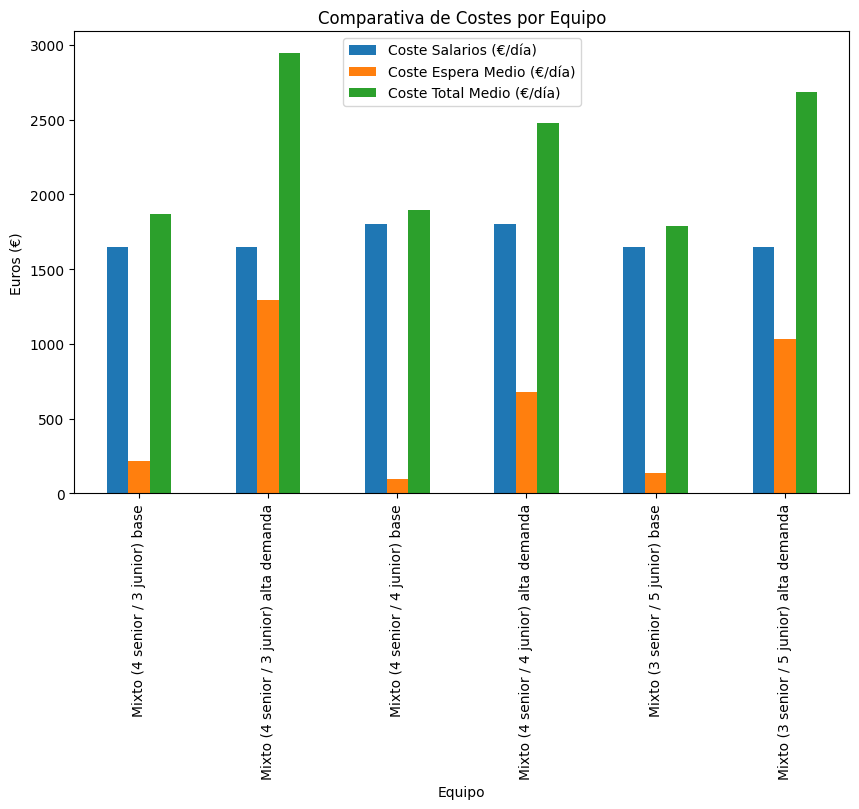

In [25]:
import matplotlib.pyplot as plt

# 1. Seleccionamos las columnas que nos interesan para comparar costes
# Usamos el nombre del dataframe que tienes en tu notebook: df_Equipos_mixtos2
columnas_costes = ['Escenario', 'Coste Salarios (€/día)', 'Coste Espera Medio (€/día)', 'Coste Total Medio (€/día)']
df_Equipos_mixtos_simple = df_Equipos_mixtos2[columnas_costes]

# 2. Creamos la gráfica de barras
# .set_index('Escenario') hace que los nombres de los equipos salgan abajo
df_Equipos_mixtos_simple.set_index('Escenario').plot(kind='bar', figsize=(10, 6))

# 3. Ponemos títulos básicos para que se entienda
plt.title("Comparativa de Costes por Equipo")
plt.ylabel("Euros (€)")
plt.xlabel("Equipo")

# 4. Mostrar la gráfica
plt.show()

In [26]:
# Umbrales críticos
umbral_critico1 = 20  
umbral_critico2 = 30  
equipo_analizar = config_asesores_8_mixtos_1
n_jornadas = 2600

total_personas_espera_larga = 0
total_personas_atendidas = 0
total_personas_espera_corta5 = 0
total_personas_espera_corta10 = 0

resultados_por_dia = []
todas_las_esperas = []
esperas_por_hora = []

# Simulación de cada jornada (UN SOLO BUCLE)
for _ in range(n_jornadas): 
    llegadas = generacion_llegadas(15, pesos_dia) 
    esperas = simulacion_atencion(equipo_analizar, llegadas)
    
    # Guardamos datos por cliente
    for t_llegada, espera in zip(llegadas, esperas):
        espera_min = espera * 60
        todas_las_esperas.append(espera_min)
        esperas_por_hora.append({'Hora': t_llegada, 'Espera': espera_min})
    
    # Estadísticas del día
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # Guardamos el promedio del día para la gráfica
        promedio_dia = sum(esperas_minutos) / len(esperas_minutos)
        resultados_por_dia.append(promedio_dia)
        
        # Estadísticas de satisfacción
        gente_hoy_espera_menos_5 = sum(1 for m in esperas_minutos if m < 5)
        gente_hoy_espera_menos_10 = sum(1 for m in esperas_minutos if m < 10)
        
        # Acumulamos totales
        total_personas_espera_corta5 += gente_hoy_espera_menos_5
        total_personas_espera_corta10 += gente_hoy_espera_menos_10
        total_personas_atendidas += len(llegadas)
    else:
        # Si no hubo esperas, el tiempo es 0
        resultados_por_dia.append(0)

df_detallado = pd.DataFrame(esperas_por_hora)

# --- 1. ¿CADA CUÁNTO HAY COLAS LARGAS? (Histograma de Riesgo) ---
plt.figure(figsize=(10, 5))
plt.hist(todas_las_esperas, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axvline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.title("Distribución de Esperas: ¿Qué tan probable es una cola larga? (4 Senior / 4 Junior)")
plt.xlabel("Minutos de espera")
plt.ylabel("Número de clientes")
plt.legend()
plt.show()

# Gráfica de espera en cola por cliente 
plt.figure(figsize=(12, 5))
plt.scatter(df_detallado['Hora'], df_detallado['Espera'], alpha=0.1, color='blue', s=10)
plt.title("Evolución de las colas durante la jornada (4 Senior / 4 Junior)")
plt.xlabel("Hora del día")
plt.ylabel("Minutos de espera")
plt.axhline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axhline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.xticks(range(9)) # Para ver las 8 horas de jornada
plt.legend()
plt.show()

# --- HISTOGRAMA DE ESTRÉS DIARIO (Distribución de promedios diarios) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de distribución de promedios diarios
ax.hist(resultados_por_dia, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(resultados_por_dia), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(resultados_por_dia):.2f} min')
ax.axvline(np.median(resultados_por_dia), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(resultados_por_dia):.2f} min')
ax.axvline(5, color='black', linestyle='--', label='Objetivo (5 min)')
ax.set_title("Distribución de Estrés Diario (promedio por día) - 4 Senior / 4 Junior")
ax.set_xlabel("Minutos promedio de espera por día")
ax.set_ylabel("Frecuencia (número de días)")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- MÉTRICAS DE CALIDAD DE SERVICIO (SLA) ---
prob_larga20 = (np.array(todas_las_esperas) > umbral_critico1).mean() * 100
prob_larga30 = (np.array(todas_las_esperas) > umbral_critico2).mean() * 100

print(f"--- ANÁLISIS DE RIESGO (Individual) ---")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico1} min: {prob_larga20:.2f}%")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico2} min: {prob_larga30:.2f}%")

print(f"\n--- ANÁLISIS DE ESTRÉS DIARIO ---")
print(f"Media de estrés diario: {np.mean(resultados_por_dia):.2f} min")
print(f"Mediana de estrés diario: {np.median(resultados_por_dia):.2f} min")
print(f"Desviación estándar: {np.std(resultados_por_dia):.2f} min")
print(f"Mínimo (mejor día): {np.min(resultados_por_dia):.2f} min")
print(f"Máximo (peor día): {np.max(resultados_por_dia):.2f} min")
print(f"Días con estrés > 5 min: {sum(1 for x in resultados_por_dia if x > 5)} de {n_jornadas}")

print(f"\n--- ANÁLISIS GLOBAL ---")
print(f"Total de personas atendidas: {total_personas_atendidas}")
print(f"Total de personas que esperaron menos de 5 min: {total_personas_espera_corta5}")
print(f"Total de personas que esperaron menos de 10 min: {total_personas_espera_corta10}")

if total_personas_atendidas > 0:
    satisfaccion = (total_personas_espera_corta10 / total_personas_atendidas) * 100
    print(f"Porcentaje de satisfacción (espera < 10 min): {satisfaccion:.2f}%")


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

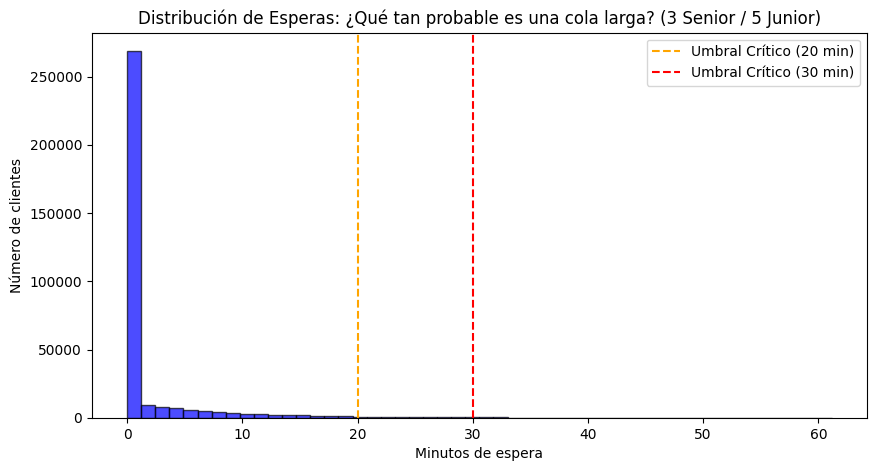

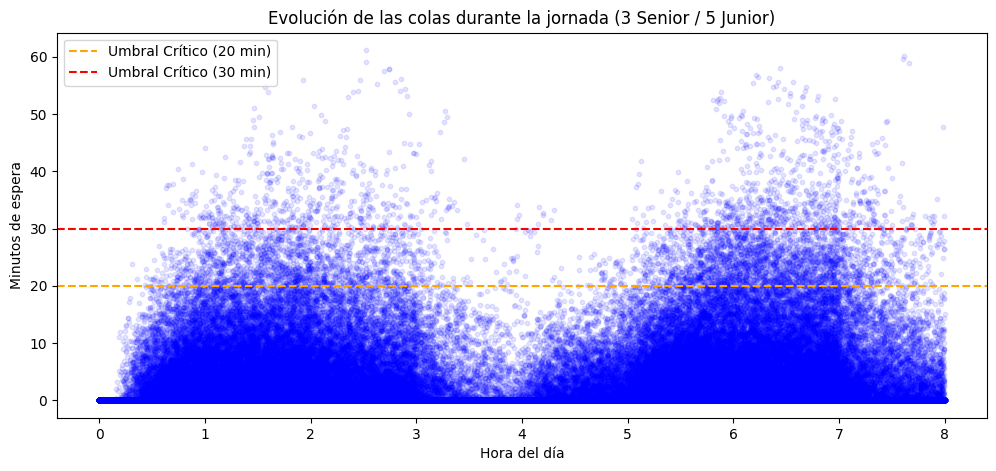

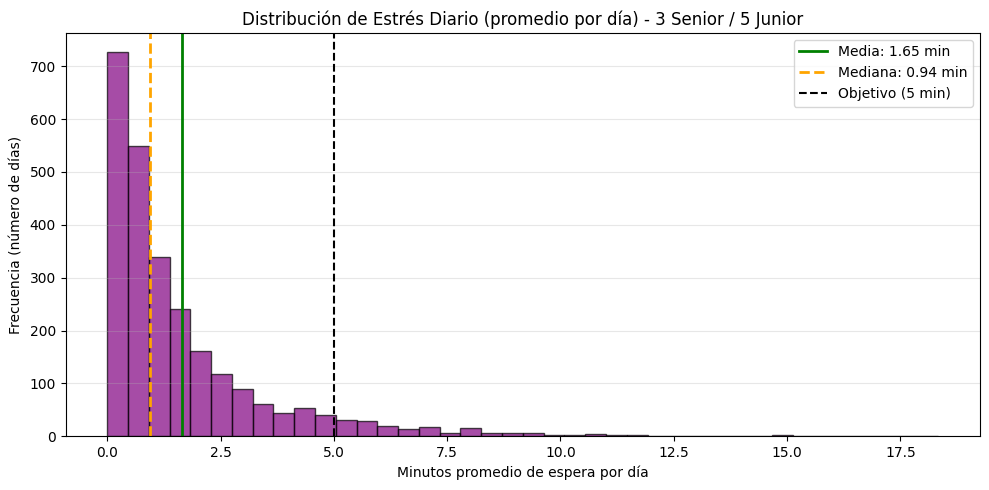

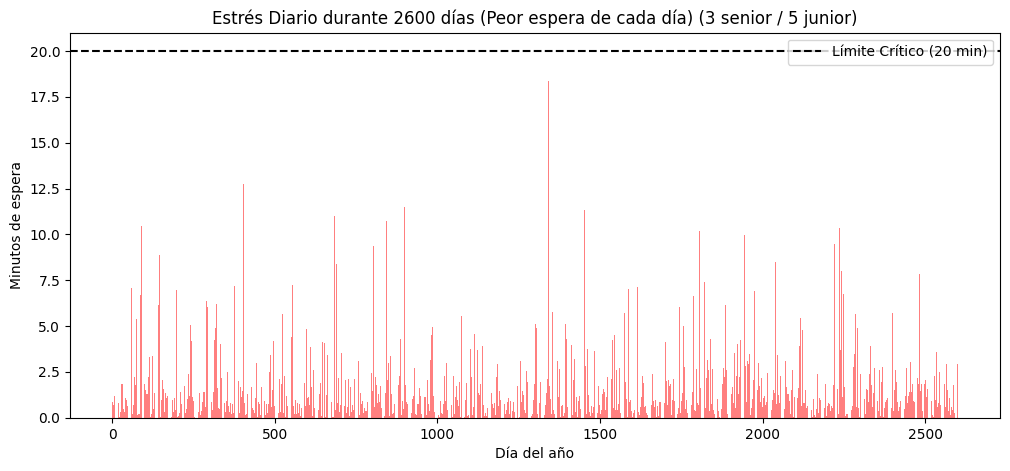

--- ANÁLISIS DE RIESGO (Individual) ---
- Probabilidad de que un cliente espere más de 20 min: 1.73%
- Probabilidad de que un cliente espere más de 30 min: 0.42%

--- ANÁLISIS DE ESTRÉS DIARIO ---
Media de estrés diario: 1.65 min
Mediana de estrés diario: 0.94 min
Desviación estándar: 1.98 min
Mínimo (mejor día): 0.00 min
Máximo (peor día): 18.34 min
Días con estrés > 5 min: 182 de 2600
Días con al menos un 'colapso' (>20 min): 0 de 2600

--- ANÁLISIS GLOBAL ---
Total de personas atendidas: 331828
Total de personas que esperaron menos de 5 min: 293228
Total de personas que esperaron menos de 10 min: 311447
Total de personas que esperaron mas de 20 min: 5731
Porcentaje de satisfacción (espera < 10 min): 93.86%
Porcentaje de insatisfacción: 1.73%


In [ ]:
# Umbrales críticos
umbral_critico1 = 20  
umbral_critico2 = 30  
equipo_analizar = config_asesores_8_mixtos_2
n_jornadas = 2600

total_personas_espera_larga = 0
total_personas_atendidas = 0
total_personas_espera_corta5 = 0
total_personas_espera_corta10 = 0

resultados_por_dia = []
todas_las_esperas = []
esperas_por_hora = []

# Simulación de cada jornada (UN SOLO BUCLE)
for _ in range(n_jornadas): 
    llegadas = generacion_llegadas(15, pesos_dia) 
    esperas = simulacion_atencion(equipo_analizar, llegadas)
    
    # Guardamos datos por cliente
    for t_llegada, espera in zip(llegadas, esperas):
        espera_min = espera * 60
        todas_las_esperas.append(espera_min)
        esperas_por_hora.append({'Hora': t_llegada, 'Espera': espera_min})
    
    # Estadísticas del día
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # Guardamos el promedio del día para la gráfica
        promedio_dia = sum(esperas_minutos) / len(esperas_minutos)
        resultados_por_dia.append(promedio_dia)
        
        # Estadísticas de satisfacción
        gente_hoy_espera_menos_5 = sum(1 for m in esperas_minutos if m < 5)
        gente_hoy_espera_menos_10 = sum(1 for m in esperas_minutos if m < 10)
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # Acumulamos totales
        total_personas_espera_corta5 += gente_hoy_espera_menos_5
        total_personas_espera_corta10 += gente_hoy_espera_menos_10
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        # Si no hubo esperas, el tiempo es 0
        resultados_por_dia.append(0)

df_detallado = pd.DataFrame(esperas_por_hora)

# --- 1. ¿CADA CUÁNTO HAY COLAS LARGAS? (Histograma de Riesgo) ---
plt.figure(figsize=(10, 5))
plt.hist(todas_las_esperas, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axvline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.title("Distribución de Esperas: ¿Qué tan probable es una cola larga? (3 Senior / 5 Junior)")
plt.xlabel("Minutos de espera")
plt.ylabel("Número de clientes")
plt.legend()
plt.show()

# Gráfica de espera en cola por cliente 
plt.figure(figsize=(12, 5))
plt.scatter(df_detallado['Hora'], df_detallado['Espera'], alpha=0.1, color='blue', s=10)
plt.title("Evolución de las colas durante la jornada (3 Senior / 5 Junior)")
plt.xlabel("Hora del día")
plt.ylabel("Minutos de espera")
plt.axhline(umbral_critico1, color='orange', linestyle='--', label=f'Umbral Crítico ({umbral_critico1} min)')
plt.axhline(umbral_critico2, color='red', linestyle='--', label=f'Umbral Crítico ({umbral_critico2} min)')
plt.xticks(range(9)) # Para ver las 8 horas de jornada
plt.legend()
plt.show()

# --- HISTOGRAMA DE ESTRÉS DIARIO (Distribución de promedios diarios) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de distribución de promedios diarios
ax.hist(resultados_por_dia, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(resultados_por_dia), color='green', linestyle='-', linewidth=2, label=f'Media: {np.mean(resultados_por_dia):.2f} min')
ax.axvline(np.median(resultados_por_dia), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {np.median(resultados_por_dia):.2f} min')
ax.axvline(5, color='black', linestyle='--', label='Objetivo (5 min)')
ax.set_title("Distribución de Estrés Diario (promedio por día) - 3 Senior / 5 Junior")
ax.set_xlabel("Minutos promedio de espera por día")
ax.set_ylabel("Frecuencia (número de días)")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_jornadas + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(umbral_critico1, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_jornadas} días (Peor espera de cada día) (3 senior / 5 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.show()

# --- MÉTRICAS DE CALIDAD DE SERVICIO (SLA) ---
prob_larga20 = (np.array(todas_las_esperas) > umbral_critico1).mean() * 100
prob_larga30 = (np.array(todas_las_esperas) > umbral_critico2).mean() * 100

print(f"--- ANÁLISIS DE RIESGO (Individual) ---")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico1} min: {prob_larga20:.2f}%")
print(f"- Probabilidad de que un cliente espere más de {umbral_critico2} min: {prob_larga30:.2f}%")

print(f"\n--- ANÁLISIS DE ESTRÉS DIARIO ---")
print(f"Media de estrés diario: {np.mean(resultados_por_dia):.2f} min")
print(f"Mediana de estrés diario: {np.median(resultados_por_dia):.2f} min")
print(f"Desviación estándar: {np.std(resultados_por_dia):.2f} min")
print(f"Mínimo (mejor día): {np.min(resultados_por_dia):.2f} min")
print(f"Máximo (peor día): {np.max(resultados_por_dia):.2f} min")
print(f"Días con estrés > 5 min: {sum(1 for x in resultados_por_dia if x > 5)} de {n_jornadas}")

print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_jornadas}")

print(f"\n--- ANÁLISIS GLOBAL ---")
print(f"Total de personas atendidas: {total_personas_atendidas}")
print(f"Total de personas que esperaron menos de 5 min: {total_personas_espera_corta5}")
print(f"Total de personas que esperaron menos de 10 min: {total_personas_espera_corta10}")
print(f"Total de personas que esperaron mas de 20 min: {total_personas_espera_larga}")

if total_personas_atendidas > 0:
    satisfaccion = (total_personas_espera_corta10 / total_personas_atendidas) * 100
    print(f"Porcentaje de satisfacción (espera < 10 min): {satisfaccion:.2f}%")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")

## Comparación de cortas esperas 

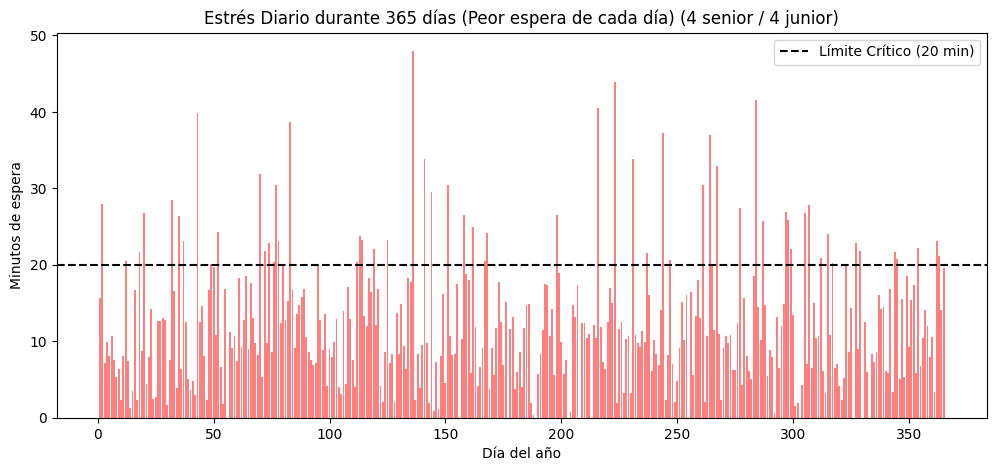

--- ANÁLISIS ANUAL ---
Total de personas atendidas al año: 46387
Total de personas que esperaron MÁS de 20 min: 504
Porcentaje de insatisfacción: 1.09%
Días con al menos un 'colapso' (>20 min): 61 de 365


In [ ]:
# 1. Configuración
n_dias = 365  # Un año completo
equipo_a_probar = config_asesores_8_mixtos_1
resultados_por_dia = []
total_personas_espera_larga = 0
total_personas_atendidas = 0

for i in range(n_dias):
    # Generamos un día de trabajo
    llegadas = generacion_llegadas(15, pesos_dia)
    esperas = simulacion_atencion(equipo_a_probar, llegadas)
    
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # A. Guardamos la peor espera del día para la gráfica
        resultados_por_dia.append(max(esperas_minutos))
        
        # B. CONTAMOS PERSONAS: ¿Cuántos clientes hoy esperaron más de 20 min?
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # C. Acumulamos totales
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_dias + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(y=20, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_dias} días (Peor espera de cada día) (4 senior / 4 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.show()

# 3. Resultados exactos
print(f"--- ANÁLISIS ANUAL ---")
print(f"Total de personas atendidas al año: {total_personas_atendidas}")
print(f"Total de personas que esperaron MÁS de 20 min: {total_personas_espera_larga}")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")
print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_dias}")

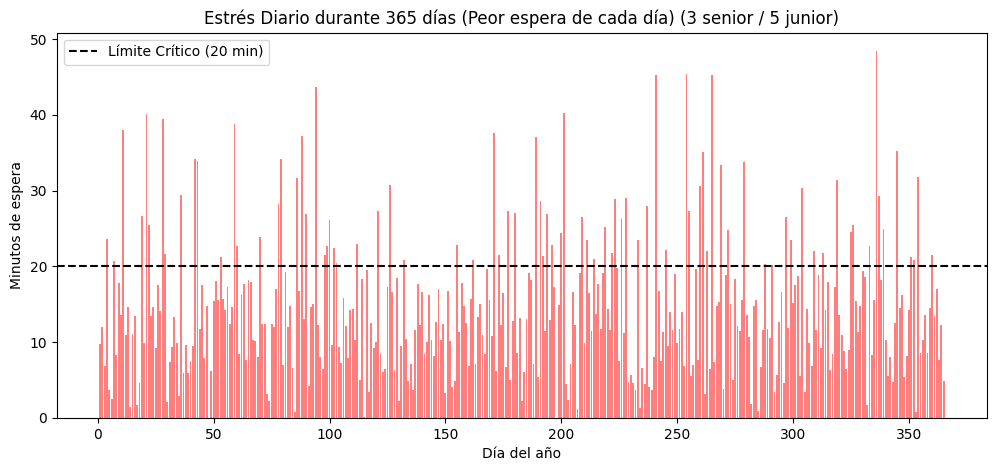

--- ANÁLISIS ANUAL ---
Total de personas atendidas al año: 46735
Total de personas que esperaron MÁS de 20 min: 863
Porcentaje de insatisfacción: 1.85%
Días con al menos un 'colapso' (>20 min): 83 de 365


In [ ]:
# 1. Configuración
n_dias = 365  # Un año completo
equipo_a_probar = config_asesores_8_mixtos_2
resultados_por_dia = []
total_personas_espera_larga = 0
total_personas_atendidas = 0

for i in range(n_dias):
    # Generamos un día de trabajo
    llegadas = generacion_llegadas(15, pesos_dia)
    esperas = simulacion_atencion(equipo_a_probar, llegadas)
    
    if esperas:
        # Convertimos todas las esperas del día a minutos
        esperas_minutos = [e * 60 for e in esperas]
        
        # A. Guardamos la peor espera del día para la gráfica
        resultados_por_dia.append(max(esperas_minutos))
        
        # B. CONTAMOS PERSONAS: ¿Cuántos clientes hoy esperaron más de 20 min?
        gente_hoy_espera_mas_20 = sum(1 for m in esperas_minutos if m > 20)
        
        # C. Acumulamos totales
        total_personas_espera_larga += gente_hoy_espera_mas_20
        total_personas_atendidas += len(llegadas)
    else:
        resultados_por_dia.append(0)

# 2. Gráfica de la "Peor Espera Diaria" (Riesgo)
plt.figure(figsize=(12, 5))
plt.bar(range(1, n_dias + 1), resultados_por_dia, color='red', alpha=0.5)
plt.axhline(y=20, color='black', linestyle='--', label='Límite Crítico (20 min)')
plt.title(f"Estrés Diario durante {n_dias} días (Peor espera de cada día) (3 senior / 5 junior)")
plt.xlabel("Día del año")
plt.ylabel("Minutos de espera")
plt.legend()
plt.show()

# 3. Resultados exactos
print(f"--- ANÁLISIS ANUAL ---")
print(f"Total de personas atendidas al año: {total_personas_atendidas}")
print(f"Total de personas que esperaron MÁS de 20 min: {total_personas_espera_larga}")
print(f"Porcentaje de insatisfacción: {(total_personas_espera_larga / total_personas_atendidas) * 100:.2f}%")
print(f"Días con al menos un 'colapso' (>20 min): {sum(1 for x in resultados_por_dia if x > 20)} de {n_dias}")

In [ ]:
df_Equipos_mixtos2

,Escenario,Iteraciones,Lambda Base,Num Asesores,Mu Promedio,Coste Espera (€/h),Configuración,Wq Medio (min),Incertidumbre (Std Dev min),Coste Salarios (€/día),Coste Espera Medio (€/día),Coste Total Medio (€/día),Factor de utilización medio
0,Mixto (4 senior / 3 junior) base,500,15,7,3.36,35,"L=15, S=7, Mu=3.4",2.46,3.00,1320,192.77,1512.77,0.678191
1,Mixto (4 senior / 3 junior) alta demanda,500,20,7,3.36,35,"L=20, S=7, Mu=3.4",11.52,10.25,1320,1186.89,2506.89,0.904255
2,Mixto (4 senior / 4 junior) base,500,15,8,3.25,35,"L=15, S=8, Mu=3.2",1.26,1.65,1440,99.27,1539.27,0.612981
3,Mixto (4 senior / 4 junior) alta demanda,500,20,8,3.25,35,"L=20, S=8, Mu=3.2",5.71,4.97,1440,582.81,2022.81,0.817308
4,Mixto (3 senior / 5 junior) base,500,15,8,3.06,35,"L=15, S=8, Mu=3.1",1.56,1.91,1320,121.91,1441.91,0.650510
5,Mixto (3 senior / 5 junior) alta demanda,500,20,8,3.06,35,"L=20, S=8, Mu=3.1",9.14,7.69,1320,939.45,2259.45,0.867347


De esta manera queda muy claro el hecho de que el equipo de 4 senior y 4 junior es el mas rentable y además es el que garatiza que cada año menos días se supere el limite critico maximo y que menos personas esperen mas de 20 minutos cualquier día

# Segunda parte: Umbral maximo de llegadas que puede soportar el equipo sin estallar

Tal y como hemos visto, el equipo de 4 senior y 4 junior el sistema con una tasa media de 15 llegadas por hora es el mas rentable y el mas eficiente entonces ahora lo vamos a poner en situaciones extremas a ver como se comporta en distintos ambitos